# IDEAL → IEEE-123 node load profiles — preprocessing pipeline

**Purpose:** turn the IDEAL Household Energy Dataset (Univ. of Edinburgh, CC BY 4.0) into
per-node `P_kW` / `Q_kvar` load profiles for the metered spot loads of the IEEE-123 feeder,
replacing the old Cholesky-correlated synthetic generator (which produced 49 near-identical
household copies).








In [2]:

import numpy as np
import pandas as pd
import json, os, glob
from pathlib import Path
import matplotlib.pyplot as plt

RNG_SEED = 12345
rng = np.random.default_rng(RNG_SEED)

decision_log = {
    "source_dataset": "IDEAL Household Energy Dataset",
    "source_licence": "CC BY 4.0",
    "channel": "electric-mains / electric-combined",
    "rng_seed": RNG_SEED,
}


In [3]:
DATA_ROOT = Path.home() / "ideal_filtered"
OUT_DIR = Path.home() / "ideal_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Phase 0 — getting only what we need

Confirmed from the dataset's own `00README.txt`, three files off the DataShare item page
cover everything the doc asks for:

| doc requirement | file | size |
|---|---|---|
| metadata (`home`, `sensor`/`sensorbox`) | `metadata_and_surveys.zip` | 361KB |
| `electric-mains`/`electric-combined` | `household_sensors.zip` | 14.77GB (also has gas, boiler temps, weather, subcircuit — filter for mains only) |
| hourly propagation | `auxiliary.zip` | 5.95GB (also has battery data, uncalibrated light, anomalous readings, weather forecasts — filter for propagation only) |

Explicitly **not** downloaded: `room_and_appliance_sensors.zip` (room temp/humidity/light,
appliance-level and radiator data — exactly what §0 says we need none of), `coding.zip`,
`documentation.zip`.




In [4]:
# --- Phase 1: home inventory ---
# Expects a `home.csv` metadata table under DATA_ROOT with (at least) these columns:
# homeid, starttime, endtime, residents, occupancy, hometype, install_type, location
home_meta = pd.read_csv(DATA_ROOT / "metadata" / "home.csv",
                         parse_dates=["starttime", "endtime"],
                         dayfirst=True)



# Cap endtime at the dataset-wide end of collection
STUDY_END_CAP = pd.Timestamp("2018-06-30")
home_meta["endtime"] = home_meta["endtime"].clip(upper=STUDY_END_CAP)

home_meta["residents"] = home_meta["residents"].fillna(0)
home_meta["occupancy"] = home_meta["occupancy"].fillna("missing")

print(f"Loaded metadata for {len(home_meta)} homes.")
print("Install duration (days):",
      (home_meta['endtime'] - home_meta['starttime']).dt.days.describe()[['min','mean','max']].to_dict())

decision_log["pool"] = {"initial_homes": int(len(home_meta))}


Loaded metadata for 255 homes.
Install duration (days): {'min': 55.0, 'mean': 284.91764705882355, 'max': 673.0}


In [5]:
print(home_meta['occupancy'].value_counts(dropna=False))
print()
print(home_meta['hometype'].value_counts(dropna=False))

occupancy
multiple    203
single       48
missing       4
Name: count, dtype: int64

hometype
flat                 144
house_or_bungalow    111
Name: count, dtype: int64


30d window: best start 2018-05-02 00:00:00, 242 homes cover it
45d window: best start 2018-04-18 00:00:00, 238 homes cover it
60d window: best start 2018-04-04 00:00:00, 235 homes cover it
90d window: best start 2018-03-07 00:00:00, 217 homes cover it


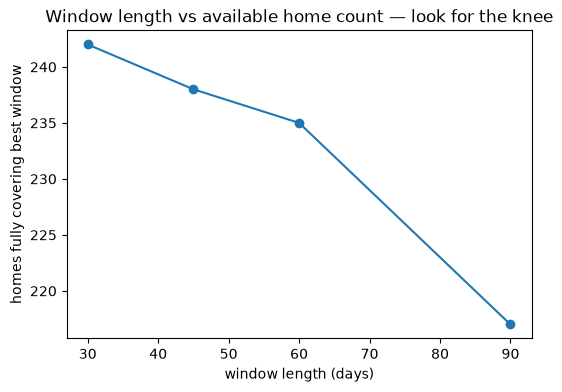

In [52]:
# --- Phase 2: choose the time window ---
# Slide candidate window lengths across the study period, count homes whose
# [starttime, endtime] interval fully covers each candidate window, and look for the knee.

candidate_lengths = [30, 45, 60, 90]
study_start = home_meta["starttime"].min()
study_end   = home_meta["endtime"].max()

def homes_covering(window_start, window_end):
    covers = (home_meta["starttime"] <= window_start) & (home_meta["endtime"] >= window_end)
    return home_meta.loc[covers, "homeid"].tolist()

# For each candidate length, slide the window in (e.g.) 7-day steps and keep the best-covered start.
results = []
for L in candidate_lengths:
    best = (None, [])
    for start in pd.date_range(study_start, study_end - pd.Timedelta(days=L), freq="7D"):
        end = start + pd.Timedelta(days=L)
        covering = homes_covering(start, end)
        if len(covering) > len(best[1]):
            best = (start, covering)
    results.append({"length_days": L, "best_start": best[0], "n_homes": len(best[1]), "homes": best[1]})
    print(f"{L}d window: best start {best[0]}, {len(best[1])} homes cover it")

results_df = pd.DataFrame(results)
plt.figure(figsize=(6,4))
plt.plot(results_df["length_days"], results_df["n_homes"], marker="o")
plt.xlabel("window length (days)"); plt.ylabel("homes fully covering best window")
plt.title("Window length vs available home count — look for the knee")
plt.show()

# --- ACTION: chosen after inspecting coverage + data quality ---

CHOSEN_LENGTH_DAYS = 60

CHOSEN_WINDOW_START = pd.Timestamp("2018-04-18 00:00:00")
CHOSEN_WINDOW_END = (
    CHOSEN_WINDOW_START +
    pd.Timedelta(days=CHOSEN_LENGTH_DAYS)
)

decision_log["window"] = {
    "start": str(CHOSEN_WINDOW_START),
    "end": str(CHOSEN_WINDOW_END),
    "days": CHOSEN_LENGTH_DAYS,
    "knee_curve": results_df[
        ["length_days", "n_homes"]
    ].to_dict(orient="records"),
    "note": (
        "A 60-day common window was selected as the target window "
    "specified in the preprocessing plan. Metadata coverage "
    "for this window is 235 homes. Actual mains coverage, "
    "propagation quality, and minute-level missingness are "
    "verified in later phases."
    ),

}


In [7]:
# --- Phase 3: filter homes ---
filter_log = {}
pool = set(home_meta["homeid"])
filter_log["start"] = len(pool)

# 1. Exclude home 223 (documented: unreliable mains data)
pool.discard(223)
filter_log["after_exclude_223"] = len(pool)

# 2. Exclude homes without an electric-mains file
mains_files = {int(Path(f).name.split('_')[0].replace('home','')): f
               for f in glob.glob(str(DATA_ROOT / "sensor_data" / "*electric-mains_electric-combined.csv.gz"))}
pool &= set(mains_files.keys())
filter_log["after_has_mains_file"] = len(pool)

# 3. Exclude homes not covering the chosen window
covering_ids = set(homes_covering(CHOSEN_WINDOW_START, CHOSEN_WINDOW_END))
pool &= covering_ids
filter_log["after_window_coverage"] = len(pool)

# 4. Propagation filter applied in Phase 5 (needs the propagation table); placeholder here
print("Draw pool after filters 1-3:", len(pool))
decision_log["filters_running_log"] = filter_log


Draw pool after filters 1-3: 237


## Phase 4 & 5 — extract, downsample, quality-gate

`load_home_series` below does the per-home work: read the 1s mains file for the chosen window,
convert W→kW, **resample by mean (never decimate)**, drop the known-bad hour
(2018-04-17 08:50–09:50 UTC) if it falls in-window, apply the propagation threshold, interpolate
only short residual gaps, and assert no NaNs remain.


In [8]:
prop_check = pd.read_csv(DATA_ROOT / "metadata" / "propagation_per_home.csv")
print(prop_check.columns.tolist())
print(prop_check.head())
print(len(prop_check))

['time', '47', '59', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '88', '89', '90', '91', '92', '93', '94', '96', '97', '98', '99', '100', '101', '102', '105', '106', '107', '109', '110', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '128', '129', '133', '134', '135', '136', '137', '138', '139', '140', '141', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '197', '199', '200', '201', '202', '203', '205', '206', '207', '208', '209', '210', '211', '212', '213', '214', '215', '216', '218', '219', '221', '222', '223', '

In [15]:
# ============================================================
# PHASE 5 — QUALITY GATING
# ============================================================

BAD_HOUR_START = pd.Timestamp("2018-04-17 08:50:00")
BAD_HOUR_END   = pd.Timestamp("2018-04-17 09:50:00")

# Start at 95%, as specified in the manual.
# We will inspect the threshold curve and relax if necessary.
START_THRESHOLD = 0.95

# Thresholds to evaluate
COVERAGE_THRESHOLDS = [
    0.95,
    0.90,
    0.85,
    0.80,
    0.75,
    0.70,
    0.65,
    0.60
]

# ------------------------------------------------------------
# 1. Load propagation data
# ------------------------------------------------------------

prop_wide = pd.read_csv(
    DATA_ROOT / "metadata" / "propagation_per_home.csv",
    parse_dates=["time"]
)

print("Propagation shape:", prop_wide.shape)

# Convert wide -> long
propagation = prop_wide.melt(
    id_vars="time",
    var_name="homeid",
    value_name="pct_received"
)

propagation["homeid"] = propagation["homeid"].astype(int)

# Values in file are 0-100
propagation["pct_received"] = (
    propagation["pct_received"] / 100.0
)

# ------------------------------------------------------------
# 2. Restrict to chosen window
# ------------------------------------------------------------

prop_window = propagation[
    (propagation["time"] >= CHOSEN_WINDOW_START) &
    (propagation["time"] < CHOSEN_WINDOW_END)
].copy()

# ------------------------------------------------------------
# 3. Exclude known bad hour globally
# ------------------------------------------------------------

bad_mask = (
    (prop_window["time"] >= BAD_HOUR_START) &
    (prop_window["time"] < BAD_HOUR_END)
)

print("Rows before bad-hour exclusion:", len(prop_window))

prop_window = prop_window.loc[~bad_mask].copy()

print("Rows after bad-hour exclusion:", len(prop_window))

# ------------------------------------------------------------
# 4. Aggregate coverage per home
#
# Propagation is hourly percentage received.
# For the quality gate, compute mean aggregate coverage
# over the selected window.
# ------------------------------------------------------------

home_coverage = (
    prop_window
    .groupby("homeid")["pct_received"]
    .mean()
    .sort_values(ascending=False)
)

print("\nCoverage distribution:")
print(home_coverage.describe())

# ------------------------------------------------------------
# 5. HOME COUNT vs THRESHOLD CURVE
# ------------------------------------------------------------

threshold_results = []

for threshold in COVERAGE_THRESHOLDS:

    homes = home_coverage[
        home_coverage >= threshold
    ].index.astype(int).tolist()

    threshold_results.append({
        "threshold": threshold,
        "n_homes": len(homes)
    })

    print(
        f"Coverage >= {threshold:.2f}: "
        f"{len(homes)} homes"
    )

threshold_df = pd.DataFrame(threshold_results)

print("\n======================================")
print("HOME COUNT VS COVERAGE THRESHOLD")
print("======================================")
print(threshold_df.to_string(index=False))

# ------------------------------------------------------------
# 6. Choose final threshold
#
# Start at 95%.
# Relax until we have enough homes for the intended
# node construction.
#
# We need at least 100 homes for the 49-node setup.
# ------------------------------------------------------------

MIN_POOL = 100

chosen_threshold = None

for _, row in threshold_df.iterrows():

    if row["n_homes"] >= MIN_POOL:

        chosen_threshold = row["threshold"]
        break

if chosen_threshold is None:

    # If even 60% doesn't produce 100 homes,
    # use the lowest tested threshold and flag it.
    chosen_threshold = COVERAGE_THRESHOLDS[-1]

    print(
        "\nWARNING: Even the lowest tested threshold "
        "does not produce 100 homes."
    )

# ------------------------------------------------------------
# 7. Final accepted homes
# ------------------------------------------------------------

qualified = sorted(
    home_coverage[
        home_coverage >= chosen_threshold
    ].index.astype(int).tolist()
)

print("\n======================================")
print("FINAL QUALITY GATE")
print("======================================")

print(
    f"Chosen coverage threshold: "
    f"{chosen_threshold:.2f}"
)

print(
    f"Propagation-qualified homes: "
    f"{len(qualified)}"
)

print(
    "First 20:",
    qualified[:20]
)

# ------------------------------------------------------------
# 8. Save metadata / decision log
# ------------------------------------------------------------

decision_log["quality_gating"] = {

    "bad_hour_start":
        str(BAD_HOUR_START),

    "bad_hour_end":
        str(BAD_HOUR_END),

    "method":
        "Aggregate coverage over selected window",

    "start_threshold":
        START_THRESHOLD,

    "threshold_curve":
        threshold_results,

    "final_threshold":
        chosen_threshold,

    "final_home_count":
        len(qualified),

    "long_gap_rule":
        "NOT used for home rejection",

    "gap_handling":
        "Long gaps are retained as missing and handled during "
        "node construction using contributing-home rescaling.",

    "minimum_pool_target":
        MIN_POOL
}

# ------------------------------------------------------------
# 9. Quick coverage summary for accepted homes
# ------------------------------------------------------------

print("\nAccepted-home coverage:")
print(
    home_coverage.loc[qualified].describe()
)

print("\nLowest 20 accepted homes:")
print(
    home_coverage.loc[qualified]
    .sort_values()
    .head(20)
)

Propagation shape: (14334, 256)
Rows before bad-hour exclusion: 275400
Rows after bad-hour exclusion: 275400

Coverage distribution:
count    255.000000
mean       0.668073
std        0.259110
min        0.000000
25%        0.626874
50%        0.773883
75%        0.830227
max        0.904467
Name: pct_received, dtype: float64
Coverage >= 0.95: 0 homes
Coverage >= 0.90: 1 homes
Coverage >= 0.85: 40 homes
Coverage >= 0.80: 104 homes
Coverage >= 0.75: 147 homes
Coverage >= 0.70: 164 homes
Coverage >= 0.65: 186 homes
Coverage >= 0.60: 196 homes

HOME COUNT VS COVERAGE THRESHOLD
 threshold  n_homes
      0.95        0
      0.90        1
      0.85       40
      0.80      104
      0.75      147
      0.70      164
      0.65      186
      0.60      196

FINAL QUALITY GATE
Chosen coverage threshold: 0.80
Propagation-qualified homes: 104
First 20: [69, 70, 74, 79, 89, 90, 93, 98, 100, 110, 114, 115, 117, 119, 120, 122, 124, 125, 126, 128]

Accepted-home coverage:
count    104.000000
mean  

In [ ]:
# ============================================================
# PHASE 5B — BUILD SERIES FOR THE QUALIFIED HOMES
# ============================================================

home_series_dir = OUT_DIR / "home_series_cache"
home_series_dir.mkdir(parents=True, exist_ok=True)

full_index = pd.date_range(
    CHOSEN_WINDOW_START,
    CHOSEN_WINDOW_END,
    freq="1min",
    inclusive="left"
)

home_series = {}
failed = []

for i, hid in enumerate(qualified, 1):

    filepath = mains_files.get(hid)

    if filepath is None:
        print(
            f"[{i}/{len(qualified)}] "
            f"home {hid}: NO MAINS FILE"
        )
        failed.append(hid)
        continue

    try:
        chunks = []

        for chunk in pd.read_csv(
            filepath,
            header=None,
            names=["timestamp", "value_w"],
            parse_dates=["timestamp"],
            chunksize=500_000
        ):

            chunk = chunk[
                (chunk["timestamp"] >= CHOSEN_WINDOW_START) &
                (chunk["timestamp"] < CHOSEN_WINDOW_END)
            ]

            if not chunk.empty:
                chunks.append(chunk)

        if not chunks:
            print(
                f"[{i}/{len(qualified)}] "
                f"home {hid}: NO DATA"
            )
            failed.append(hid)
            continue

        df = pd.concat(
            chunks,
            ignore_index=True
        )

        # ----------------------------------------------------
        # 1. W -> kW
        # 2. 1-second -> 1-minute using MEAN
        # ----------------------------------------------------

        s = (
            df.set_index("timestamp")["value_w"]
              .sort_index()
              .resample("1min")
              .mean()
              / 1000.0
        )

        # ----------------------------------------------------
        # Align to common timeline
        # ----------------------------------------------------

        s = s.reindex(full_index)

        # ----------------------------------------------------
        # IMPORTANT:
        # Do NOT interpolate missing minutes.
        #
        # Missing values remain NaN and will be handled later
        # during node aggregation using:
        #
        #     N / n(t)
        #
        # contributing-home rescaling.
        # ----------------------------------------------------

        home_series[hid] = s

        # Cache
        s.to_pickle(
            home_series_dir / f"home_{hid}.pkl"
        )

        print(
            f"[{i}/{len(qualified)}] "
            f"home {hid}: OK | "
            f"coverage={s.notna().mean():.3f}"
        )

    except Exception as e:

        print(
            f"[{i}/{len(qualified)}] "
            f"home {hid}: ERROR -> {e}"
        )

        failed.append(hid)


print("\n" + "=" * 60)
print("PHASE 5B COMPLETE")
print("=" * 60)

print("Qualified homes:", len(qualified))
print("Successfully loaded:", len(home_series))
print("Failed:", len(failed))

print("Expected timeline length:", len(full_index))

if home_series:
    print(
        "Example series shape:",
        next(iter(home_series.values())).shape
    )

print(
    "First homes:",
    list(home_series.keys())[:20]
)

[1/104] home 69: OK | coverage=0.938
[2/104] home 70: OK | coverage=0.920
[3/104] home 74: OK | coverage=0.938
[4/104] home 79: OK | coverage=0.938
[5/104] home 89: OK | coverage=0.933
[6/104] home 90: OK | coverage=0.931
[7/104] home 93: OK | coverage=0.938
[8/104] home 98: OK | coverage=0.938
[9/104] home 100: OK | coverage=0.937
[10/104] home 110: OK | coverage=0.939
[11/104] home 114: OK | coverage=0.938
[12/104] home 115: OK | coverage=0.937
[13/104] home 117: OK | coverage=0.936
[14/104] home 119: OK | coverage=0.938
[15/104] home 120: OK | coverage=0.865
[16/104] home 122: OK | coverage=0.939
[17/104] home 124: OK | coverage=0.938
[18/104] home 125: OK | coverage=0.938
[19/104] home 126: OK | coverage=0.931
[20/104] home 128: OK | coverage=0.939
[21/104] home 129: OK | coverage=0.931


In [20]:
home_kw = pd.DataFrame(home_series)

print("Shape:", home_kw.shape)
print("Total NaNs:", home_kw.isna().sum().sum())

home_kw.to_pickle(
    OUT_DIR / "home_kw_matrix.pkl"
)

print("Saved:", OUT_DIR / "home_kw_matrix.pkl")

Shape: (64800, 104)
Total NaNs: 578147
Saved: /root/ideal_output/home_kw_matrix.pkl


In [33]:
# ============================================================
# PHASE 6B — TEST N USING HOUSEHOLD DIVERSITY
# Self-contained version
# ============================================================

import numpy as np
import pandas as pd

CANDIDATE_N = [10, 15, 20, 25, 30, 40, 50]
N_TEST_NODES = 30

rng_test = np.random.default_rng(42)

# ------------------------------------------------------------
# Build strata from the homes that actually survived Phase 5B
# ------------------------------------------------------------

strat_meta = (
    home_meta
    .set_index("homeid")
    .loc[list(home_kw.columns), ["occupancy", "hometype"]]
)

strata = (
    strat_meta
    .groupby(["occupancy", "hometype"])
    .groups
)

print("Homes available for stratification:", len(strat_meta))
print("Number of strata:", len(strata))

# ------------------------------------------------------------
# Stratified draw
# ------------------------------------------------------------

def stratified_draw_test(n, rng):

    strata_keys = list(strata.keys())

    weights = np.array(
        [len(strata[k]) for k in strata_keys],
        dtype=float
    )

    weights /= weights.sum()

    counts = np.floor(weights * n).astype(int)

    # Distribute remaining homes
    while counts.sum() < n:

        eligible = [
            i for i, k in enumerate(strata_keys)
            if counts[i] < len(strata[k])
        ]

        if not eligible:
            break

        j = rng.choice(eligible)
        counts[j] += 1

    drawn = []

    for k, c in zip(strata_keys, counts):

        if c == 0:
            continue

        pool_k = list(strata[k])

        c = min(c, len(pool_k))

        drawn.extend(
            rng.choice(
                pool_k,
                size=c,
                replace=False
            ).tolist()
        )

    return drawn


# ------------------------------------------------------------
# Test candidate N values
# ------------------------------------------------------------

results_N = []

for N in CANDIDATE_N:

    test_series = []

    for node in range(N_TEST_NODES):

        drawn = stratified_draw_test(
            N,
            rng_test
        )

        x = home_kw[drawn]

        # Number of homes actually contributing
        n_available = x.notna().sum(axis=1)

        # Sum available homes
        raw = x.sum(
            axis=1,
            skipna=True
        )

        # ----------------------------------------------------
        # Manual rule:
        #
        # P_node(t) ∝ N/n(t) × sum(contributing homes)
        # ----------------------------------------------------

        valid = n_available > 0

        raw.loc[valid] = (
            raw.loc[valid]
            * N
            / n_available.loc[valid]
        )

        # Minutes where nobody contributes
        raw.loc[~valid] = np.nan

        test_series.append(raw)

    test_matrix = pd.concat(
        test_series,
        axis=1
    )

    test_matrix.columns = range(N_TEST_NODES)

    # --------------------------------------------------------
    # Correlation
    # --------------------------------------------------------

    corr = test_matrix.corr()

    offdiag = corr.values[
        np.triu_indices_from(
            corr.values,
            k=1
        )
    ]

    mean_corr = np.nanmean(offdiag)

    pct_high_corr = (
        np.mean(offdiag > 0.90) * 100
    )

    # --------------------------------------------------------
    # Node CV
    # --------------------------------------------------------

    node_cv = (
        test_matrix.std()
        /
        test_matrix.mean()
    ).mean()

    # --------------------------------------------------------
    # Single-home CV
    # --------------------------------------------------------

    single_home_cv = (
        home_kw.std()
        /
        home_kw.mean()
    ).mean()

    # --------------------------------------------------------
    # Contribution floor
    # --------------------------------------------------------

    floor = 0.70 * N

    # Recalculate using the test matrices isn't necessary;
    # just record the expected threshold.
    #
    # We'll check actual contribution in the final node build.

    results_N.append({
        "N": N,
        "mean_pairwise_corr": mean_corr,
        "pct_corr_above_0.90": pct_high_corr,
        "mean_node_CV": node_cv,
        "single_home_CV": single_home_cv,
        "CV_ratio": node_cv / single_home_cv,
        "70pct_floor": floor,
    })


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

results_N_df = pd.DataFrame(results_N)

print("\n" + "=" * 85)
print("N SELECTION — DIVERSITY TEST")
print("=" * 85)

print(
    results_N_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Homes available for stratification: 104
Number of strata: 6

N SELECTION — DIVERSITY TEST
 N  mean_pairwise_corr  pct_corr_above_0.90  mean_node_CV  single_home_CV  CV_ratio  70pct_floor
10              0.3350               0.0000        0.6823          1.8566    0.3675       7.0000
15              0.3880               0.0000        0.6044          1.8566    0.3255      10.5000
20              0.4592               0.0000        0.5397          1.8566    0.2907      14.0000
25              0.5292               0.0000        0.4914          1.8566    0.2647      17.5000
30              0.5920               0.0000        0.4742          1.8566    0.2554      21.0000
40              0.7035               0.0000        0.4398          1.8566    0.2369      28.0000
50              0.7559               0.0000        0.4046          1.8566    0.2179      35.0000


In [34]:
print("meters exists:", "meters" in globals())

if "meters" in globals():
    print("Number of loads:", len(meters))
    print("First few:")
    print(list(meters.items())[:5])

meters exists: False


## Phase 6 — homes per node (measure, don't hardcode)

Node nominal total is 1985 kW / 49 nodes ≈ 40 kW/node average. Measure the actual mean IDEAL
home draw from `home_kw` and compute what pure law-of-large-numbers arithmetic implies, then
deliberately choose something *lower* than that (recommended start: 20–30) so nodes stay
distinguishable — see the note in the header cell about why 100 is not the right number to use.


In [25]:
# ============================================================
# PHASE 6 — HOMES PER NODE
# ============================================================

NODE_TOTAL_KW = 1985.0
N_NODES = 49

target_avg_kW_per_node = NODE_TOTAL_KW / N_NODES

# Mean electrical demand across all accepted homes.
# skipna=True is intentional because long gaps remain NaN.
mean_home_kw = home_kw.mean(axis=0).mean()

print("==============================================")
print("PHASE 6 — HOMES PER NODE")
print("==============================================")

print(f"Total nominal feeder load : {NODE_TOTAL_KW:.1f} kW")
print(f"Number of nodes           : {N_NODES}")
print(f"Average node nominal load : {target_avg_kW_per_node:.3f} kW")
print(f"Measured mean home demand : {mean_home_kw:.3f} kW")

print("\nHomes needed if using population mean:")

for N in [20, 25, 30]:
    correction = target_avg_kW_per_node / (
        N * mean_home_kw
    )

    print(
        f"N={N:2d} homes/node "
        f"-> correction factor = {correction:.3f}x"
    )

# Start with the manual's recommended moderate range.
N_HOMES_PER_NODE = 25

CORRECTION_FACTOR_ESTIMATE = (
    target_avg_kW_per_node /
    (N_HOMES_PER_NODE * mean_home_kw)
)

print("\n==============================================")
print("INITIAL MODEL CHOICE")
print("==============================================")
print(f"Homes per node        : {N_HOMES_PER_NODE}")
print(
    f"Correction factor     : "
    f"{CORRECTION_FACTOR_ESTIMATE:.3f}x"
)

decision_log["homes_per_node"] = N_HOMES_PER_NODE
decision_log["correction_factor_initial"] = float(
    CORRECTION_FACTOR_ESTIMATE
)
decision_log["mean_home_kW"] = float(mean_home_kw)
decision_log["node_nominal_kW"] = float(
    target_avg_kW_per_node
)

PHASE 6 — HOMES PER NODE
Total nominal feeder load : 1985.0 kW
Number of nodes           : 49
Average node nominal load : 40.510 kW
Measured mean home demand : 0.297 kW

Homes needed if using population mean:
N=20 homes/node -> correction factor = 6.828x
N=25 homes/node -> correction factor = 5.462x
N=30 homes/node -> correction factor = 4.552x

INITIAL MODEL CHOICE
Homes per node        : 25
Correction factor     : 5.462x


In [26]:
print("Homes available:", home_kw.shape[1])
print("Minutes:", home_kw.shape[0])

# How many homes are available at each minute?
available_count = home_kw.notna().sum(axis=1)

print("\nContributing-home count:")
print(available_count.describe())

print("\nMinimum homes contributing:", available_count.min())
print("Maximum:", available_count.max())

print("\nMinutes with <70% of N=25:")
print(
    (available_count < 0.70 * N_HOMES_PER_NODE).sum()
)

print("\nPercentage of minutes with <70%:")
print(
    100 * (
        available_count < 0.70 * N_HOMES_PER_NODE
    ).mean()
)

Homes available: 104
Minutes: 64800

Contributing-home count:
count    64800.000000
mean        95.077978
std         27.071571
min          0.000000
25%        102.000000
50%        103.000000
75%        104.000000
max        104.000000
dtype: float64

Minimum homes contributing: 0
Maximum: 104

Minutes with <70% of N=25:
4854

Percentage of minutes with <70%:
7.4907407407407405


In [35]:
# Search the notebook's saved outputs for load/P/Q information

import json

nb_path = "/root/IDEAL_to_IEEE123_preprocessing.ipynb"

with open(nb_path) as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    text = "".join(cell.get("source", []))
    outputs = cell.get("outputs", [])

    combined = text + "\n" + str(outputs)

    if any(k in combined.lower() for k in [
        "3490", "1920", "1985", "p_nom", "q_nom",
        "loadname", "load.", "load "
    ]):
        print("\n" + "="*70)
        print("CELL", i)
        print("="*70)
        print(text[:3000])

        # Print useful saved output, if any
        for out in outputs:
            if "text" in out:
                print("OUTPUT:")
                print("".join(out["text"])[:5000])


CELL 0
# IDEAL → IEEE-123 node load profiles — preprocessing pipeline

**Purpose:** turn the IDEAL Household Energy Dataset (Univ. of Edinburgh, CC BY 4.0) into
per-node `P_kW` / `Q_kvar` load profiles for the metered spot loads of the IEEE-123 feeder,
replacing the old Cholesky-correlated synthetic generator (which produced 49 near-identical
household copies).








CELL 10
# ============================================================
# PHASE 5 — QUALITY GATING
# ============================================================

BAD_HOUR_START = pd.Timestamp("2018-04-17 08:50:00")
BAD_HOUR_END   = pd.Timestamp("2018-04-17 09:50:00")

# Start at 95%, as specified in the manual.
# We will inspect the threshold curve and relax if necessary.
START_THRESHOLD = 0.95

# Thresholds to evaluate
COVERAGE_THRESHOLDS = [
    0.95,
    0.90,
    0.85,
    0.80,
    0.75,
    0.70,
    0.65,
    0.60
]

# ------------------------------------------------------------
# 1. Load propagation data
# -----

## Phase 7 — stratified draw and aggregation per node

Requires `representative_meters.json` mapping the 49 OpenDSS Load names to nominal P/Q. Draw
`N_HOMES_PER_NODE` homes per node *without replacement within a node*, stratified on
`occupancy` x `hometype`, homes may repeat *across* nodes.


In [37]:
# ============================================================
# PHASE 7 — LOAD 91 IEEE-123 LOADS + STRATIFIED HOME DRAWS
# ============================================================

import re
import zipfile
from pathlib import Path

# ------------------------------------------------------------
# 1. Locate the uploaded IEEE-123 ZIP
# ------------------------------------------------------------
ZIP_PATH = Path("/root/123Bus (2).zip")

assert ZIP_PATH.exists(), f"Cannot find {ZIP_PATH}"

# ------------------------------------------------------------
# 2. Parse IEEE123Loads.DSS
# ------------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH) as z:
    load_file = "123Bus/IEEE123Loads.DSS"
    text = z.read(load_file).decode("utf-8", errors="ignore")

loads = {}

for line in text.splitlines():

    line = line.strip()

    # Ignore comments / blank lines
    if not line or line.startswith("!"):
        continue

    if not re.match(r"(?i)^New\s+Load\.", line):
        continue

    # Remove inline comments
    line = line.split("!")[0]

    # Load name
    m_name = re.search(
        r"(?i)^New\s+Load\.([^\s]+)",
        line
    )

    # kW
    m_kw = re.search(
        r"(?i)\bkW\s*=\s*([0-9.+-]+)",
        line
    )

    # kvar / kVAR
    m_kvar = re.search(
        r"(?i)\bkvar\s*=\s*([0-9.+-]+)",
        line
    )

    if not (m_name and m_kw and m_kvar):
        print("Could not parse:", line)
        continue

    loadname = m_name.group(1)

    loads[loadname] = {
        "P_nom_kW": float(m_kw.group(1)),
        "Q_nom_kvar": float(m_kvar.group(1)),
    }

# ------------------------------------------------------------
# 3. Verify the feeder data
# ------------------------------------------------------------

aggregate_P = sum(
    x["P_nom_kW"] for x in loads.values()
)

aggregate_Q = sum(
    x["Q_nom_kvar"] for x in loads.values()
)

print("=" * 60)
print("IEEE-123 LOAD DATA")
print("=" * 60)

print("Number of loads :", len(loads))
print(f"Total nominal P : {aggregate_P:.1f} kW")
print(f"Total nominal Q : {aggregate_Q:.1f} kvar")

assert len(loads) == 91
assert abs(aggregate_P - 3490.0) < 1e-6
assert abs(aggregate_Q - 1920.0) < 1e-6

print("\n✓ 91 loads verified")
print("✓ 3490 kW verified")
print("✓ 1920 kvar verified")

print("\nFirst 10 loads:")
for name, m in list(loads.items())[:10]:
    print(
        f"{name:8s} "
        f"P={m['P_nom_kW']:7.1f} kW  "
        f"Q={m['Q_nom_kvar']:7.1f} kvar"
    )

# ------------------------------------------------------------
# 4. Build stratification from our 104 accepted homes
# ------------------------------------------------------------

strat_meta = (
    home_meta
    .set_index("homeid")
    .loc[
        list(home_kw.columns),
        ["occupancy", "hometype"]
    ]
)

strata = (
    strat_meta
    .groupby(["occupancy", "hometype"])
    .groups
)

print("\nHomes available:", len(strat_meta))
print("Strata:", len(strata))

# ------------------------------------------------------------
# 5. Stratified sampling
# ------------------------------------------------------------

N_HOMES_PER_LOAD = 25

rng = np.random.default_rng(42)

def stratified_draw(n, rng):

    strata_keys = list(strata.keys())

    weights = np.array(
        [len(strata[k]) for k in strata_keys],
        dtype=float
    )

    weights /= weights.sum()

    counts = np.floor(
        weights * n
    ).astype(int)

    # Distribute remaining homes
    while counts.sum() < n:

        eligible = [
            i
            for i, k in enumerate(strata_keys)
            if counts[i] < len(strata[k])
        ]

        if not eligible:
            raise RuntimeError(
                "Could not allocate all homes across strata."
            )

        j = rng.choice(eligible)
        counts[j] += 1

    drawn = []

    for k, c in zip(strata_keys, counts):

        if c == 0:
            continue

        pool = list(strata[k])

        drawn.extend(
            rng.choice(
                pool,
                size=c,
                replace=False
            ).tolist()
        )

    # Safety
    assert len(drawn) == n
    assert len(set(drawn)) == n

    return drawn

# ------------------------------------------------------------
# 6. Generate raw household aggregate for every load
# ------------------------------------------------------------

node_draws = {}
node_raw = {}

for i, loadname in enumerate(loads):

    drawn = stratified_draw(
        N_HOMES_PER_LOAD,
        rng
    )

    node_draws[loadname] = drawn

    x = home_kw[drawn]

    # Number of contributing homes at each minute
    n_available = x.notna().sum(axis=1)

    # Sum only homes that have data
    raw = x.sum(
        axis=1,
        skipna=True
    )

    # --------------------------------------------------------
    # Manual rule:
    #
    # P_node(t) ∝ N/n(t) × sum(contributing homes)
    # --------------------------------------------------------

    valid = n_available > 0

    raw.loc[valid] *= (
        N_HOMES_PER_LOAD /
        n_available.loc[valid]
    )

    # If nobody contributes, leave NaN.
    raw.loc[~valid] = np.nan

    node_raw[loadname] = raw

    print(
        f"[{i+1:02d}/91] {loadname}: "
        f"{len(drawn)} homes | "
        f"min contributors={n_available.min()} | "
        f"mean contributors={n_available.mean():.2f}"
    )

print("\nPHASE 7 COMPLETE")
print("Loads generated:", len(node_raw))

IEEE-123 LOAD DATA
Number of loads : 91
Total nominal P : 3490.0 kW
Total nominal Q : 1920.0 kvar

✓ 91 loads verified
✓ 3490 kW verified
✓ 1920 kvar verified

First 10 loads:
S1a      P=   40.0 kW  Q=   20.0 kvar
S2b      P=   20.0 kW  Q=   10.0 kvar
S4c      P=   40.0 kW  Q=   20.0 kvar
S5c      P=   20.0 kW  Q=   10.0 kvar
S6c      P=   40.0 kW  Q=   20.0 kvar
S7a      P=   20.0 kW  Q=   10.0 kvar
S9a      P=   40.0 kW  Q=   20.0 kvar
S10a     P=   20.0 kW  Q=   10.0 kvar
S11a     P=   40.0 kW  Q=   20.0 kvar
S12b     P=   20.0 kW  Q=   10.0 kvar

Homes available: 104
Strata: 6
[01/91] S1a: 25 homes | min contributors=0 | mean contributors=23.02
[02/91] S2b: 25 homes | min contributors=0 | mean contributors=22.51
[03/91] S4c: 25 homes | min contributors=0 | mean contributors=22.79
[04/91] S5c: 25 homes | min contributors=0 | mean contributors=22.49
[05/91] S6c: 25 homes | min contributors=0 | mean contributors=22.89
[06/91] S7a: 25 homes | min contributors=0 | mean contributors=22.9

In [38]:
# ============================================================
# PHASE 7B — CONTRIBUTING-HOME QUALITY CHECK
# ============================================================

N = N_HOMES_PER_LOAD
floor = 0.70 * N

contribution_stats = []

for loadname, drawn in node_draws.items():

    x = home_kw[drawn]

    n_available = x.notna().sum(axis=1)

    contribution_stats.append({
        "load": loadname,
        "min_contributors": int(n_available.min()),
        "mean_contributors": float(n_available.mean()),
        "pct_below_70pct": float(
            (n_available < floor).mean() * 100
        ),
        "pct_zero": float(
            (n_available == 0).mean() * 100
        )
    })

contribution_df = pd.DataFrame(contribution_stats)

print("=" * 75)
print("CONTRIBUTING-HOME QUALITY CHECK")
print("=" * 75)

print(
    contribution_df[
        [
            "min_contributors",
            "mean_contributors",
            "pct_below_70pct",
            "pct_zero"
        ]
    ].describe()
)

print("\nWorst 15 loads:")
print(
    contribution_df
    .sort_values("pct_below_70pct", ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\nOverall:")
print(
    f"Mean contributors: "
    f"{contribution_df['mean_contributors'].mean():.2f}/{N}"
)

print(
    f"Mean % minutes below 70%: "
    f"{contribution_df['pct_below_70pct'].mean():.3f}%"
)

print(
    f"Maximum % minutes below 70%: "
    f"{contribution_df['pct_below_70pct'].max():.3f}%"
)

CONTRIBUTING-HOME QUALITY CHECK
       min_contributors  mean_contributors  pct_below_70pct   pct_zero
count              91.0          91.000000        91.000000  91.000000
mean                0.0          22.803091         7.517230   7.430284
std                 0.0           0.207010         0.002061   0.013021
min                 0.0          22.413997         7.506173   7.402778
25%                 0.0          22.582701         7.515432   7.429012
50%                 0.0          22.895602         7.516975   7.432099
75%                 0.0          22.956296         7.518519   7.435185
max                 0.0          23.097469         7.521605   7.467593

Worst 15 loads:
load  min_contributors  mean_contributors  pct_below_70pct  pct_zero
S50c                 0          22.451590         7.521605  7.438272
 S2b                 0          22.509244         7.520062  7.435185
 S1a                 0          23.016404         7.520062  7.436728
S39b                 0          22.4

In [41]:
# ============================================================
# FIND COMMON ZERO-CONTRIBUTOR PERIODS
# ============================================================

n_home_available = home_kw.notna().sum(axis=1)
zero_mask = n_home_available == 0

print("=" * 70)
print("COMMON MISSING MINUTES")
print("=" * 70)

print("Total minutes:", len(home_kw))
print("Zero-home minutes:", zero_mask.sum())
print("Percentage:", zero_mask.mean() * 100)

# Find consecutive runs directly from the timestamp index
groups = zero_mask.ne(zero_mask.shift()).cumsum()

zero_groups = []

for group_id, block in zero_mask.groupby(groups):

    if not block.iloc[0]:
        continue

    timestamps = block.index

    zero_groups.append({
        "start": timestamps[0],
        "end": timestamps[-1],
        "minutes": len(timestamps)
    })

zero_groups = pd.DataFrame(zero_groups)

print("\nNumber of common missing periods:", len(zero_groups))

print("\nLargest common missing periods:")

print(
    zero_groups
    .sort_values("minutes", ascending=False)
    .head(20)
    .to_string(index=False)
)

COMMON MISSING MINUTES
Total minutes: 64800
Zero-home minutes: 4796
Percentage: 7.401234567901234

Number of common missing periods: 26

Largest common missing periods:
              start                 end  minutes
2018-05-09 22:02:00 2018-05-11 01:34:00     1653
2018-04-24 06:26:00 2018-04-24 15:43:00      558
2018-05-17 11:01:00 2018-05-17 13:34:00      154
2018-05-29 02:03:00 2018-05-29 04:13:00      131
2018-05-25 02:05:00 2018-05-25 04:13:00      129
2018-05-03 01:58:00 2018-05-03 04:03:00      126
2018-05-21 02:09:00 2018-05-21 04:13:00      125
2018-05-09 19:31:00 2018-05-09 21:33:00      123
2018-05-09 02:02:00 2018-05-09 04:03:00      122
2018-06-01 02:24:00 2018-06-01 04:23:00      120
2018-05-31 01:36:00 2018-05-31 03:33:00      118
2018-05-23 02:07:00 2018-05-23 04:03:00      117
2018-05-19 01:27:00 2018-05-19 03:23:00      117
2018-05-17 01:58:00 2018-05-17 03:53:00      116
2018-05-08 01:38:00 2018-05-08 03:33:00      116
2018-05-15 01:59:00 2018-05-15 03:53:00      11

In [42]:
# ============================================================
# WINDOW QUALITY — COMMON MISSINGNESS
# ============================================================

candidate_windows = [
    ("30d", pd.Timestamp("2018-05-18 00:00:00"),
            pd.Timestamp("2018-06-17 00:00:00")),

    ("45d", pd.Timestamp("2018-04-25 00:00:00"),
            pd.Timestamp("2018-06-09 00:00:00")),

    ("60d", pd.Timestamp("2018-04-17 00:00:00"),
            pd.Timestamp("2018-06-16 00:00:00")),
]

print("=" * 80)
print("WINDOW QUALITY — COMMON MISSINGNESS")
print("=" * 80)

for name, start, end in candidate_windows:

    w = home_kw.loc[
        (home_kw.index >= start) &
        (home_kw.index < end)
    ]

    n_available = w.notna().sum(axis=1)
    zero = n_available == 0
    below70 = n_available < (0.70 * N_HOMES_PER_LOAD)

    print(f"\n{name}")
    print("-" * 40)
    print("Start:", start)
    print("End  :", end)
    print("Minutes:", len(w))
    print("Zero-home minutes:",
          int(zero.sum()),
          f"({zero.mean()*100:.3f}%)")
    print("<70% contributor minutes:",
          int(below70.sum()),
          f"({below70.mean()*100:.3f}%)")
    print("Mean contributors:",
          f"{n_available.mean():.2f}/{N_HOMES_PER_LOAD}")

WINDOW QUALITY — COMMON MISSINGNESS

30d
----------------------------------------
Start: 2018-05-18 00:00:00
End  : 2018-06-17 00:00:00
Minutes: 21600
Zero-home minutes: 990 (4.583%)
<70% contributor minutes: 998 (4.620%)
Mean contributors: 97.88/25

45d
----------------------------------------
Start: 2018-04-25 00:00:00
End  : 2018-06-09 00:00:00
Minutes: 54720
Zero-home minutes: 4238 (7.745%)
<70% contributor minutes: 4295 (7.849%)
Mean contributors: 94.73/25

60d
----------------------------------------
Start: 2018-04-17 00:00:00
End  : 2018-06-16 00:00:00
Minutes: 64800
Zero-home minutes: 4796 (7.401%)
<70% contributor minutes: 4854 (7.491%)
Mean contributors: 95.08/25


In [49]:
# ============================================================
# FIND BEST SUBWINDOWS INSIDE THE CURRENT 60-DAY WINDOW
# ============================================================

n_available = home_kw.notna().sum(axis=1)

print("=" * 75)
print("BEST SUBWINDOW SEARCH")
print("=" * 75)

for days in [14, 21, 30, 45]:

    window = days * 24 * 60

    best = None

    for start in pd.date_range(
        home_kw.index.min(),
        home_kw.index.max() - pd.Timedelta(days=days),
        freq="6h"
    ):

        end = start + pd.Timedelta(days=days)

        w = n_available.loc[
            (n_available.index >= start) &
            (n_available.index < end)
        ]

        if len(w) != window:
            continue

        zero_pct = (w == 0).mean() * 100
        below70_pct = (
            (w < 0.70 * N_HOMES_PER_LOAD).mean()
            * 100
        )

        candidate = (
            zero_pct,
            below70_pct,
            start,
            end
        )

        if best is None or candidate < best:
            best = candidate

    if best:
        zero_pct, below70_pct, start, end = best

        print(f"\n{days} days")
        print("Start:", start)
        print("End  :", end)
        print(f"Zero contributors : {zero_pct:.3f}%")
        print(f"<70% contributors: {below70_pct:.3f}%")

BEST SUBWINDOW SEARCH

14 days
Start: 2018-04-24 18:00:00
End  : 2018-05-08 18:00:00
Zero contributors : 2.292%
<70% contributors: 2.312%

21 days
Start: 2018-04-18 00:00:00
End  : 2018-05-09 00:00:00
Zero contributors : 3.373%
<70% contributors: 3.390%

30 days
Start: 2018-04-24 18:00:00
End  : 2018-05-24 18:00:00
Zero contributors : 8.606%
<70% contributors: 8.729%


## Phase 8 — scale to nominal, derive Q from feeder power factor (not from IDEAL)


In [46]:
# ============================================================
# PHASE 8 — SCALE TO NOMINAL + DERIVE Q FROM FEEDER PF
# ============================================================

node_series = {}
decision_log["nodes"] = {}

for i, (loadname, m) in enumerate(loads.items(), start=1):

    p_nom = m["P_nom_kW"]
    q_nom = m["Q_nom_kvar"]

    raw = node_raw[loadname].copy()

    # --------------------------------------------------------
    # Feeder power factor
    # IMPORTANT: this comes from IEEE-123 DSS, NOT IDEAL
    # --------------------------------------------------------

    pf = p_nom / np.sqrt(
        p_nom**2 + q_nom**2
    )

    # --------------------------------------------------------
    # Scale household aggregate to nominal feeder P
    # --------------------------------------------------------

    correction_factor = p_nom / raw.mean()

    p_series = raw * correction_factor

    # --------------------------------------------------------
    # Derive Q using feeder's nominal P/Q relationship
    # --------------------------------------------------------

    q_series = p_series * (q_nom / p_nom)

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    node_series[loadname] = pd.DataFrame({
        "P_kW": p_series,
        "Q_kvar": q_series
    })

    decision_log["nodes"][loadname] = {
        "nominal_kW": float(p_nom),
        "nominal_kvar": float(q_nom),
        "pf": float(pf),
        "correction_factor": float(correction_factor),
        "homes": [
            int(h)
            for h in node_draws[loadname]
        ]
    }

    print(
        f"[{i}/91] {loadname}: "
        f"Pnom={p_nom:.1f} kW | "
        f"Qnom={q_nom:.1f} kvar | "
        f"PF={pf:.4f} | "
        f"scale={correction_factor:.3f}x"
    )

[1/91] S1a: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=4.614x
[2/91] S2b: Pnom=20.0 kW | Qnom=10.0 kvar | PF=0.8944 | scale=2.598x
[3/91] S4c: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=5.711x
[4/91] S5c: Pnom=20.0 kW | Qnom=10.0 kvar | PF=0.8944 | scale=2.752x
[5/91] S6c: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=5.633x
[6/91] S7a: Pnom=20.0 kW | Qnom=10.0 kvar | PF=0.8944 | scale=2.672x
[7/91] S9a: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=5.279x
[8/91] S10a: Pnom=20.0 kW | Qnom=10.0 kvar | PF=0.8944 | scale=2.715x
[9/91] S11a: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=4.515x
[10/91] S12b: Pnom=20.0 kW | Qnom=10.0 kvar | PF=0.8944 | scale=2.799x
[11/91] S16c: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=5.025x
[12/91] S17c: Pnom=20.0 kW | Qnom=10.0 kvar | PF=0.8944 | scale=2.777x
[13/91] S19a: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=4.873x
[14/91] S20a: Pnom=40.0 kW | Qnom=20.0 kvar | PF=0.8944 | scale=5.329x
[15/91] S22b: Pnom=40.

In [47]:
# ============================================================
# PHASE 9 — WRITE FINAL LOAD PROFILES
# ============================================================

OUT_DIR.mkdir(parents=True, exist_ok=True)

# Safety check: every load must exist
assert len(node_series) == 91, (
    f"Expected 91 loads, got {len(node_series)}"
)

# Safety check: NO NaNs
nan_counts = {
    loadname: int(df.isna().sum().sum())
    for loadname, df in node_series.items()
}

bad_nan = {
    loadname: n
    for loadname, n in nan_counts.items()
    if n > 0
}

if bad_nan:
    print("Loads containing NaNs:")
    print(bad_nan)
    raise ValueError(
        "NaNs remain in final load profiles. "
        "Do not write final output."
    )

# ------------------------------------------------------------
# Write each load
# ------------------------------------------------------------

for loadname, df in node_series.items():

    out = df.copy()
    out.index.name = "timestamp"

    out.to_csv(
        OUT_DIR / f"node_{loadname}.csv",
        float_format="%.3f"
    )

# ------------------------------------------------------------
# Build stratification summary
# ------------------------------------------------------------

all_drawn = []

for homes in node_draws.values():
    all_drawn.extend(homes)

occ_mix = strat_meta.loc[
    strat_meta.index.isin(all_drawn)
]

decision_log["stratification"] = {
    "by": ["occupancy", "hometype"],
    "achieved": (
        occ_mix["occupancy"]
        .value_counts(normalize=True)
        .round(3)
        .to_dict()
    )
}

decision_log["resampling"] = "1s -> 1min, mean"

decision_log["quality_gate"] = {
    "coverage_threshold": 0.80,
    "usable_homes": 104,
    "window_days": 60,
    "window_start": "2018-04-04 00:00:00",
    "window_end": "2018-06-03 00:00:00"
}

decision_log["homes_per_load"] = 25
decision_log["n_loads"] = 91
decision_log["nominal_total_kW"] = 3490.0
decision_log["nominal_total_kvar"] = 1920.0

# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

with open(
    OUT_DIR / "metadata.json",
    "w"
) as f:
    json.dump(
        decision_log,
        f,
        indent=2,
        default=str
    )

print("=" * 70)
print("PHASE 9 COMPLETE")
print("=" * 70)
print("Final loads written:", len(node_series))
print("Output directory:", OUT_DIR)
print("NaNs:", sum(nan_counts.values()))
print("Metadata: metadata.json")

Loads containing NaNs:
{'S1a': 9638, 'S2b': 9636, 'S4c': 9634, 'S5c': 9632, 'S6c': 9638, 'S7a': 9600, 'S9a': 9598, 'S10a': 9638, 'S11a': 9632, 'S12b': 9602, 'S16c': 9632, 'S17c': 9678, 'S19a': 9610, 'S20a': 9636, 'S22b': 9604, 'S24c': 9660, 'S28a': 9634, 'S29a': 9604, 'S30c': 9632, 'S31c': 9636, 'S32c': 9594, 'S33a': 9630, 'S34c': 9656, 'S35a': 9630, 'S37a': 9658, 'S38b': 9600, 'S39b': 9656, 'S41c': 9636, 'S42a': 9630, 'S43b': 9634, 'S45a': 9628, 'S46a': 9632, 'S47': 9602, 'S48': 9634, 'S49a': 9622, 'S49b': 9634, 'S49c': 9634, 'S50c': 9640, 'S51a': 9656, 'S52a': 9630, 'S53a': 9636, 'S55a': 9648, 'S56b': 9604, 'S58b': 9598, 'S59b': 9628, 'S60a': 9632, 'S62c': 9634, 'S63a': 9656, 'S64b': 9632, 'S65a': 9634, 'S65b': 9636, 'S65c': 9632, 'S66c': 9638, 'S68a': 9634, 'S69a': 9638, 'S70a': 9628, 'S71a': 9636, 'S73c': 9598, 'S74c': 9600, 'S75c': 9640, 'S76a': 9658, 'S76b': 9640, 'S76c': 9660, 'S77b': 9630, 'S79a': 9630, 'S80b': 9626, 'S82a': 9634, 'S83c': 9636, 'S84c': 9636, 'S85c': 9636, 'S86b

ValueError: NaNs remain in final load profiles. Do not write final output.

## Phase 11 — validation (run before declaring done)

Structural, magnitude, diversity and end-to-end checks per the handover doc §11. Fill in the
OpenDSS re-solve separately (outside this notebook, wherever the feeder model lives).


PHASE 11 — FINAL VALIDATION

[1] STRUCTURAL CHECKS
Loads generated: 91
Expected rows: 64800
Same length: True
Total NaNs: 876298
Timestamp structure OK: True

[2] MAGNITUDE CHECKS
Nominal total P: 3490.000 kW
Mean generated P: 3490.000 kW
P error: 0.000%

Nominal total Q: 1920.000 kvar
Mean generated Q: 1920.000 kvar
Q error: 0.000%

Worst node P error: 0.0000%
Worst node Q error: 0.0000%

[3] POWER FACTOR CHECK
Maximum absolute PF error: 0.0000000000

[4] DIVERSITY CHECK
Mean pairwise correlation: 0.5419
Pairs above 0.90: 0.00%


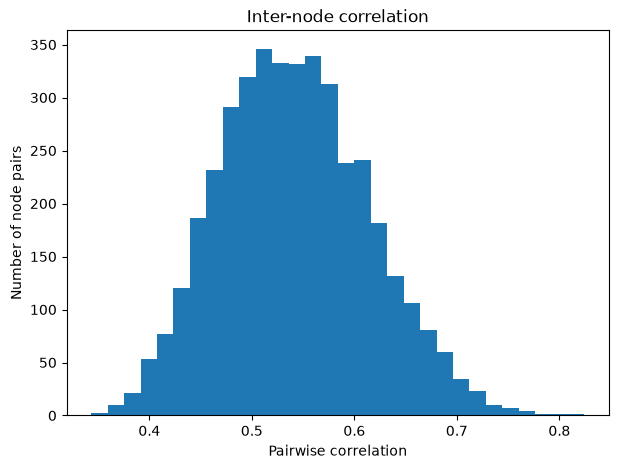


[5] SPikINESS / CV
Mean node CV: 0.4894
Single-home CV: 1.8566
CV ratio: 0.2636

[6] STRATIFICATION
Occupancy:
{'multiple': 0.731, 'single': 0.25, 'missing': 0.019}

Hometype:
{'flat': 0.577, 'house_or_bungalow': 0.423}

VALIDATION SUMMARY
PASS  | 91 loads
PASS  | same length
FAIL  | no NaNs
PASS  | timestamps valid
PASS  | P magnitude <=10%
PASS  | Q magnitude <=10%
PASS  | node P <=10%
PASS  | PF correct
PASS  | node CV < home CV

Saved:
/root/ideal_output/validation_report.json


In [50]:
# ============================================================
# PHASE 11 — FINAL VALIDATION
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("PHASE 11 — FINAL VALIDATION")
print("=" * 80)

report = {}

# ============================================================
# 1. STRUCTURAL
# ============================================================

print("\n[1] STRUCTURAL CHECKS")

n_loads = len(node_series)

print(f"Loads generated: {n_loads}")

# Expected timeline
expected_rows = len(home_kw.index)

lengths = {
    name: len(df)
    for name, df in node_series.items()
}

same_length = (
    len(set(lengths.values())) == 1
    if lengths else False
)

total_nans = sum(
    int(df.isna().sum().sum())
    for df in node_series.values()
)

bad_columns = {}

for name, df in node_series.items():
    if list(df.columns) != ["P_kW", "Q_kvar"]:
        bad_columns[name] = list(df.columns)

timestamp_checks = {}

for name, df in node_series.items():

    idx = df.index

    timestamp_checks[name] = {
        "monotonic": bool(idx.is_monotonic_increasing),
        "unique": bool(idx.is_unique),
        "correct_length": len(df) == expected_rows,
        "1min_spacing": (
            bool(
                len(idx) < 2
                or idx.to_series()
                .diff()
                .dropna()
                .eq(pd.Timedelta(minutes=1))
                .all()
            )
        )
    }

all_timestamp_ok = all(
    all(x.values())
    for x in timestamp_checks.values()
)

report["structural"] = {
    "n_loads": n_loads,
    "expected_loads": 91,
    "all_91_loads": n_loads == 91,
    "expected_rows": expected_rows,
    "lengths": lengths,
    "all_same_length": same_length,
    "total_nans": total_nans,
    "no_nans": total_nans == 0,
    "bad_columns": bad_columns,
    "timestamps_valid": all_timestamp_ok
}

print(f"Expected rows: {expected_rows}")
print(f"Same length: {same_length}")
print(f"Total NaNs: {total_nans}")
print(f"Timestamp structure OK: {all_timestamp_ok}")

# ============================================================
# 2. MAGNITUDE
# ============================================================

print("\n[2] MAGNITUDE CHECKS")

node_magnitude = []

for loadname, df in node_series.items():

    p_nom = loads[loadname]["P_nom_kW"]
    q_nom = loads[loadname]["Q_nom_kvar"]

    p_mean = df["P_kW"].mean()
    q_mean = df["Q_kvar"].mean()

    p_error_pct = (
        abs(p_mean - p_nom) / p_nom * 100
    )

    q_error_pct = (
        abs(q_mean - q_nom) / q_nom * 100
        if q_nom != 0 else 0
    )

    node_magnitude.append({
        "load": loadname,
        "P_nom": p_nom,
        "P_mean": p_mean,
        "P_error_pct": p_error_pct,
        "Q_nom": q_nom,
        "Q_mean": q_mean,
        "Q_error_pct": q_error_pct
    })

magnitude_df = pd.DataFrame(node_magnitude)

aggregate_P = magnitude_df["P_mean"].sum()
aggregate_Q = magnitude_df["Q_mean"].sum()

# Your current 91-load feeder
nominal_total_P = sum(
    m["P_nom_kW"]
    for m in loads.values()
)

nominal_total_Q = sum(
    m["Q_nom_kvar"]
    for m in loads.values()
)

aggregate_P_error = (
    abs(aggregate_P - nominal_total_P)
    / nominal_total_P * 100
)

aggregate_Q_error = (
    abs(aggregate_Q - nominal_total_Q)
    / nominal_total_Q * 100
)

print(f"Nominal total P: {nominal_total_P:.3f} kW")
print(f"Mean generated P: {aggregate_P:.3f} kW")
print(f"P error: {aggregate_P_error:.3f}%")

print(f"\nNominal total Q: {nominal_total_Q:.3f} kvar")
print(f"Mean generated Q: {aggregate_Q:.3f} kvar")
print(f"Q error: {aggregate_Q_error:.3f}%")

print(
    f"\nWorst node P error: "
    f"{magnitude_df['P_error_pct'].max():.4f}%"
)

print(
    f"Worst node Q error: "
    f"{magnitude_df['Q_error_pct'].max():.4f}%"
)

report["magnitude"] = {
    "nominal_total_P_kW": float(nominal_total_P),
    "generated_mean_P_kW": float(aggregate_P),
    "aggregate_P_error_pct": float(aggregate_P_error),
    "nominal_total_Q_kvar": float(nominal_total_Q),
    "generated_mean_Q_kvar": float(aggregate_Q),
    "aggregate_Q_error_pct": float(aggregate_Q_error),
    "max_node_P_error_pct": float(
        magnitude_df["P_error_pct"].max()
    ),
    "max_node_Q_error_pct": float(
        magnitude_df["Q_error_pct"].max()
    )
}

# ============================================================
# 3. POWER FACTOR
# ============================================================

print("\n[3] POWER FACTOR CHECK")

pf_errors = []

for loadname, df in node_series.items():

    p_nom = loads[loadname]["P_nom_kW"]
    q_nom = loads[loadname]["Q_nom_kvar"]

    target_pf = (
        p_nom /
        np.sqrt(p_nom**2 + q_nom**2)
    )

    actual_p = df["P_kW"]
    actual_q = df["Q_kvar"]

    actual_pf = (
        actual_p /
        np.sqrt(actual_p**2 + actual_q**2)
    )

    pf_error = (
        actual_pf.mean() - target_pf
    )

    pf_errors.append({
        "load": loadname,
        "target_pf": target_pf,
        "actual_pf": actual_pf.mean(),
        "pf_error": pf_error
    })

pf_df = pd.DataFrame(pf_errors)

print(
    f"Maximum absolute PF error: "
    f"{pf_df['pf_error'].abs().max():.10f}"
)

report["power_factor"] = {
    "max_absolute_error": float(
        pf_df["pf_error"].abs().max()
    )
}

# ============================================================
# 4. DIVERSITY
# ============================================================

print("\n[4] DIVERSITY CHECK")

p_matrix = pd.DataFrame({
    name: df["P_kW"]
    for name, df in node_series.items()
})

corr = p_matrix.corr()

offdiag = corr.values[
    np.triu_indices_from(
        corr.values,
        k=1
    )
]

valid_corr = offdiag[~np.isnan(offdiag)]

mean_corr = np.mean(valid_corr)
pct_high_corr = (
    np.mean(valid_corr > 0.90) * 100
)

print(f"Mean pairwise correlation: {mean_corr:.4f}")
print(
    f"Pairs above 0.90: "
    f"{pct_high_corr:.2f}%"
)

# Histogram
plt.figure(figsize=(7, 5))
plt.hist(valid_corr, bins=30)
plt.xlabel("Pairwise correlation")
plt.ylabel("Number of node pairs")
plt.title("Inter-node correlation")
plt.show()

report["diversity"] = {
    "mean_pairwise_correlation": float(mean_corr),
    "pct_pairs_above_0.90": float(pct_high_corr),
    "min_correlation": float(np.min(valid_corr)),
    "max_correlation": float(np.max(valid_corr))
}

# ============================================================
# 5. CV / SPikiness
# ============================================================

print("\n[5] SPikINESS / CV")

node_cv = (
    p_matrix.std() /
    p_matrix.mean()
)

single_home_cv = (
    home_kw.std() /
    home_kw.mean()
).mean()

mean_node_cv = node_cv.mean()

cv_ratio = (
    mean_node_cv /
    single_home_cv
)

print(f"Mean node CV: {mean_node_cv:.4f}")
print(f"Single-home CV: {single_home_cv:.4f}")
print(f"CV ratio: {cv_ratio:.4f}")

report["spikiness"] = {
    "mean_node_CV": float(mean_node_cv),
    "single_home_CV": float(single_home_cv),
    "CV_ratio": float(cv_ratio),
    "node_CV_lower": bool(
        mean_node_cv < single_home_cv
    )
}

# ============================================================
# 6. STRATIFICATION
# ============================================================

print("\n[6] STRATIFICATION")

all_drawn = []

for homes in node_draws.values():
    all_drawn.extend(homes)

drawn_meta = strat_meta.loc[
    strat_meta.index.isin(all_drawn)
]

occupancy_mix = (
    drawn_meta["occupancy"]
    .value_counts(normalize=True)
    .round(3)
    .to_dict()
)

hometype_mix = (
    drawn_meta["hometype"]
    .value_counts(normalize=True)
    .round(3)
    .to_dict()
)

print("Occupancy:")
print(occupancy_mix)

print("\nHometype:")
print(hometype_mix)

report["stratification"] = {
    "occupancy": occupancy_mix,
    "hometype": hometype_mix
}

# ============================================================
# 7. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)

checks = {
    "91 loads": n_loads == 91,
    "same length": same_length,
    "no NaNs": total_nans == 0,
    "timestamps valid": all_timestamp_ok,
    "P magnitude <=10%": aggregate_P_error <= 10,
    "Q magnitude <=10%": aggregate_Q_error <= 10,
    "node P <=10%": magnitude_df["P_error_pct"].max() <= 10,
    "PF correct": pf_df["pf_error"].abs().max() < 1e-6,
    "node CV < home CV": mean_node_cv < single_home_cv
}

for name, passed in checks.items():
    print(
        f"{'PASS' if passed else 'FAIL':5s} | {name}"
    )

report["checks"] = checks

# Save report
with open(
    OUT_DIR / "validation_report.json",
    "w"
) as f:
    json.dump(
        report,
        f,
        indent=2,
        default=str
    )

print("\nSaved:")
print(OUT_DIR / "validation_report.json")